In [1]:
import requests

# pip install beautifulsoup4
from bs4 import BeautifulSoup

# https://www.weather.go.kr/ > 관측기후 > 육상 > 도시별관측
response = requests.get("https://www.weather.go.kr/w/obs-climate/land/city-obs.do")
soup = BeautifulSoup(response.content, 'html.parser')

table = soup.find('table', id='weather_table')

table

trs = table.find_all('tr')

data = []
for tr in trs:

    th = tr.find('th').find('a')

    if not th: # None 값 제거
        continue

    point = th.text

    if tr.find_all('td'):
        temperature = tr.find_all('td')[4].text
        humidity = tr.find_all('td')[8].text

    # print([point, temperature, humidity])

    data.append([point, temperature, humidity])

data




[['강릉', '35.0', '45'],
 ['강진군', '33.7', '60'],
 ['강화', '28.8', '75'],
 ['거제', '30.5', '67'],
 ['거창', '33.3', '50'],
 ['경주시', '36.0', '37'],
 ['고산', '30.8', '74'],
 ['고창', '31.1', '70'],
 ['고창군', '32.3', '65'],
 ['고흥', '32.7', '66'],
 ['광양시', '33.1', '64'],
 ['광주', '31.4', '66'],
 ['구미', '33.9', '46'],
 ['군산', '31.0', '72'],
 ['금산', '32.1', '56'],
 ['김해시', '33.0', '61'],
 ['남원', '31.1', '68'],
 ['남해', '32.0', '65'],
 ['대관령', '27.3', '61'],
 ['대구', '34.7', '43'],
 ['대전', '31.9', '58'],
 ['동두천', '30.4', '74'],
 ['동해', '32.9', '53'],
 ['목포', '31.6', '68'],
 ['문경', '29.1', '73'],
 ['밀양', '33.5', '44'],
 ['백령도', '29.5', '68'],
 ['보령', '30.8', '78'],
 ['보성군', '32.8', '71'],
 ['보은', '29.4', '71'],
 ['부산', '31.8', '61'],
 ['부안', '31.1', '68'],
 ['부여', '31.1', '69'],
 ['북강릉', '34.7', '40'],
 ['북부산', '32.9', '61'],
 ['북창원', '33.9', '57'],
 ['북춘천', '31.7', '59'],
 ['산청', '33.8', '53'],
 ['상주', '32.2', '60'],
 ['서귀포', '31.1', '73'],
 ['서산', '28.6', '82'],
 ['서울', '31.8', '62'],
 ['서청주', '29.5', '72

In [2]:
with open('weather.csv', 'w', encoding='UTF8') as file:
    file.write('point, temperature, humidity\n')
    for i in data:
        file.write(f'{i[0]},{i[1]},{i[2]}\n')

In [3]:
# matplotlib.pyplot의 show 함수를 호출하지 않아도 주피터 노트북 안에서 그래프가 표시됨
# %matplotlib inline
# pip install pandas
import pandas as pd # 데이터 처리

# csv 파일을 읽어서 DataFrame 객체로 만듦. 인덱스 항목(컬럼)은 point로 설정
# df = pd.read_csv('weather.csv')
df = pd.read_csv('weather.csv', index_col='point')
df



,temperature,humidity
point,,
강릉,35.0,45
강진군,33.7,60
강화,28.8,75
거제,30.5,67
거창,33.3,50
...,...,...
합천,34.8,41
해남,31.9,71
홍성,30.3,82


In [4]:
# 특별시, 광역시만 모아서 DataFrame 객체로 만듦
# loc 속성은 label-location의 약자로 레이블을 지정해 특정 인덱스의 데이터만 가져오는데 씀
city_df = df.loc[['서울', '인천', '대전', '대구', '광주', '부산', '울산']]
city_df

,temperature,humidity
point,,
서울,31.8,62
인천,29.6,68
대전,31.9,58
대구,34.7,43
광주,31.4,66
부산,31.8,61
울산,33.4,52


(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, '서울'),
  Text(1, 0, '인천'),
  Text(2, 0, '대전'),
  Text(3, 0, '대구'),
  Text(4, 0, '광주'),
  Text(5, 0, '부산'),
  Text(6, 0, '울산')])

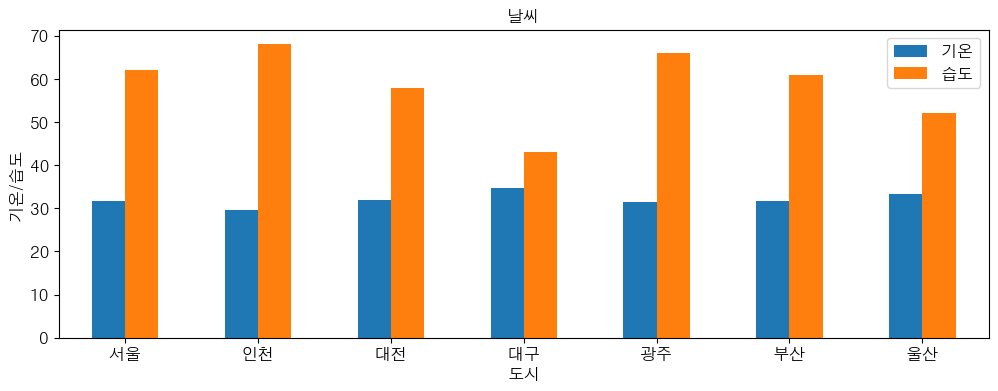

In [6]:
# Windows 한글 폰트 설정해야 함!
# pip install matplotlib
from matplotlib import font_manager, rc
import matplotlib.pyplot as plt

# AttributeError: module 'matplotlib' has no attribute 'font_manager' 에러가 발생하면 해당 코드를 주석 처리한 후 실행한 후, 주석 해제 후 다시 실행하면 됨
# .get_name() 누락 주의!!!
font_path = 'C:/Windows/Fonts/H2GTRM.TTF'
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

# 차트 종류, 제목, 차트 크기, 범례, 폰트 크기 설정
# ax = city_df.plot() # 이 코드에서 속성을 하나씩 붙여 갈 것!
ax = city_df.plot(kind='bar', title='날씨', figsize=(12, 4), legend=True, fontsize=12)
ax.set_xlabel('도시', fontsize=12)          # x축 정보 표시
ax.set_ylabel('기온/습도', fontsize=12)     # y축 정보 표시
ax.legend(['기온', '습도'], fontsize=12)    # 범례 지정
plt.xticks(rotation=0)

# import matplotlib.pyplot as plt # IDLE, 파이썬 인터프리터에서 그래프 표시할 경우
# plt.show()